# Task 3 (Advanced) — AI-Driven NLP: Deploying & Analyzing Language Models
**ShadowFox AIML Internship**

**Problem statement:** Embark on an AI-driven journey in NLP/ML by **deploying a Language Model (LM) of choice**. Implement the chosen LM in a Jupyter notebook from scratch, conduct an **in-depth analysis** of its performance and capabilities, define **research questions** on its strengths and limitations, consider **ethical implications**, and draw conclusions.

## 1. Language Model selection 🧭

**Task requirement:** *"Choose an LM aligned with your interests — cutting-edge models like GPT-3, BERT, or even a specialized domain-specific LM."*

I deploy **two complementary open-source models** so the project covers both fundamental LM abilities — *understanding* text and *generating* text:

| | 🤗 **DistilBERT** (SST-2 fine-tuned) | 🤗 **DistilGPT-2** |
|---|---|---|
| Kind | **Encoder-only** Transformer | **Decoder-only** Transformer |
| Learns by | reading the *whole* sentence at once | predicting the *next token*, left → right |
| Best at | understanding tasks (sentiment, classification) | open-ended text generation |
| Size | 66M parameters | 82M parameters |
| Why chosen | distilled from BERT — 40% smaller, 60% faster, ~97% of the accuracy | distilled GPT-2 — coherent, lightweight, runs on CPU |

**Why not GPT-3/BERT-large directly?** These run **free on a free CPU**, download in seconds via Hugging Face, and the *methodology* (tokenize → transformer → task head / next-token loop) is identical to the giants — exactly what a from-scratch analysis needs.

### Research questions guiding this project
- **RQ1 — Robustness:** can a fine-tuned sentiment LM handle **negation** ("this was *not* good"), where humans flip polarity effortlessly?
- **RQ2 — Calibration:** is the classifier **overconfident** on ambiguous, neutral, or sarcastic input?
- **RQ3 — Controllability:** how do generation **parameters** (temperature, top-k, top-p) change creativity vs. coherence — measured, not vibes?

Plus an **ethical probe**: does sentiment scoring depend on gendered names/pronouns when the content is identical?

## 2. Implementation — setting up the deployment

In [1]:
%%capture
import time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from transformers import pipeline, AutoTokenizer, set_seed

set_seed(42)                      # reproducible generations
pd.set_option("display.max_colwidth", 160)

print("transformers:", transformers.__version__, "| torch:", torch.__version__)
print("date:", datetime.date.today())

In [2]:
# --- Deploy the two LMs (downloads happen once, then they are cached) ---
t0 = time.time()
sentiment_lm = pipeline("sentiment-analysis",
                        model="distilbert-base-uncased-finetuned-sst-2-english")
generator_lm = pipeline("text-generation", model="distilgpt2")
print(f"Both LMs deployed in {time.time()-t0:.1f}s — running locally on CPU, no API keys, no cost.")

Both LMs deployed in 2.2s — running locally on CPU, no API keys, no cost.


## 3. Under the hood — how an LM actually reads your text 🔍
Before trusting the magic, we peek inside. Every LLM does the same three steps:

1. **Tokenization** — splits text into *tokens* (word pieces). Rare words break into chunks: *"unbelievable"* → `un`, `##believ`, `##able`.
2. **ID mapping** — each token becomes an integer ID (position in the model's 30k–50k vocabulary).
3. **Transformer layers** — **self-attention** lets every token "look at" every other token to build meaning; special tokens `[CLS]` (sentence summary) and `[SEP]` (separator) wrap the input.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

sentence = "The ShadowFox internship is unbelievably exciting!"
encoded = tokenizer(sentence)

print("RAW TEXT :", sentence)
print("\nTOKENS   :", tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("\nTOKEN IDs:", encoded["input_ids"])
print("\nATTENTION MASK:", encoded["attention_mask"], "  <- 1 = real token, 0 = padding")
print("\nVocab size of this model:", tokenizer.vocab_size, "tokens")

RAW TEXT : The ShadowFox internship is unbelievably exciting!

TOKENS   : ['[CLS]', 'the', 'shadow', '##fo', '##x', 'internship', 'is', 'un', '##bel', '##ie', '##va', '##bly', 'exciting', '!', '[SEP]']

TOKEN IDs: [101, 1996, 5192, 14876, 2595, 22676, 2003, 4895, 8671, 2666, 3567, 6321, 10990, 999, 102]

ATTENTION MASK: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]   <- 1 = real token, 0 = padding

Vocab size of this model: 30522 tokens


**Key parameters highlighted** (we use them later): `max_new_tokens` (how much text to generate),
`temperature` (randomness), `top_k` / `top_p` (how many candidate next-tokens are considered),
`num_return_sequences` (how many independent outputs).

---

# PART A — DistilBERT: understanding text (sentiment analysis)

## 4. Baseline capability test — a small labeled benchmark
We build a tiny benchmark of **12 sentences with known ground truth**, including mixed domains
(reviews, cricket commentary, tech, food) — and measure plain accuracy.

In [4]:
benchmark = [
    # (text, true label)
    ("This phone is absolutely brilliant, the camera blew me away.", "POSITIVE"),
    ("Worst purchase of my life. It broke within two days.", "NEGATIVE"),
    ("Virat's cover drive in the final over was a treat to watch, pure class!", "POSITIVE"),
    ("The pitch was terrible and the match dragged on boringly.", "NEGATIVE"),
    ("The support team resolved my issue in minutes, super impressed.", "POSITIVE"),
    ("Food arrived cold, late, and the order was wrong.", "NEGATIVE"),
    ("An average experience; nothing great, nothing awful either.", "NEUTRAL-HARD"),   # deliberately hard
    ("I loved every page of this book, couldn't put it down.", "POSITIVE"),
    ("The interface is confusing, slow and full of bugs.", "NEGATIVE"),
    ("What a fantastic monsoon this year — the farmers are happy.", "POSITIVE"),
    ("The hotel room smelled of smoke and the sheets were dirty.", "NEGATIVE"),
    ("Oh wonderful, the meeting got extended by two more hours.", "SARCASM"),         # deliberately hard
]

rows = []
for text, truth in benchmark:
    out = sentiment_lm(text)[0]
    rows.append({"text": text[:60] + "…" if len(text) > 60 else text,
                 "true": truth, "model": out["label"], "confidence": round(out["score"], 3)})

df_bm = pd.DataFrame(rows)
clear = df_bm[df_bm["true"].isin(["POSITIVE", "NEGATIVE"])]
correct = (clear["true"] == clear["model"]).sum()
print(f"Accuracy on 10 CLEAR sentences: {correct}/10 = {correct/10:.0%}")
print("Hard cases (neutral/sarcasm) shown separately — see the table:\n")
df_bm

Accuracy on 10 CLEAR sentences: 10/10 = 100%
Hard cases (neutral/sarcasm) shown separately — see the table:



,text,true,model,confidence
0,"This phone is absolutely brilliant, the camera blew me away.",POSITIVE,POSITIVE,0.622
1,Worst purchase of my life. It broke within two days.,NEGATIVE,NEGATIVE,1.000
2,"Virat's cover drive in the final over was a treat to watch, …",POSITIVE,POSITIVE,1.000
3,The pitch was terrible and the match dragged on boringly.,NEGATIVE,NEGATIVE,1.000
4,"The support team resolved my issue in minutes, super impress…",POSITIVE,POSITIVE,1.000
5,"Food arrived cold, late, and the order was wrong.",NEGATIVE,NEGATIVE,1.000
6,"An average experience; nothing great, nothing awful either.",NEUTRAL-HARD,NEGATIVE,0.997
7,"I loved every page of this book, couldn't put it down.",POSITIVE,POSITIVE,0.999
8,"The interface is confusing, slow and full of bugs.",NEGATIVE,NEGATIVE,1.000
9,What a fantastic monsoon this year — the farmers are happy.,POSITIVE,POSITIVE,1.000


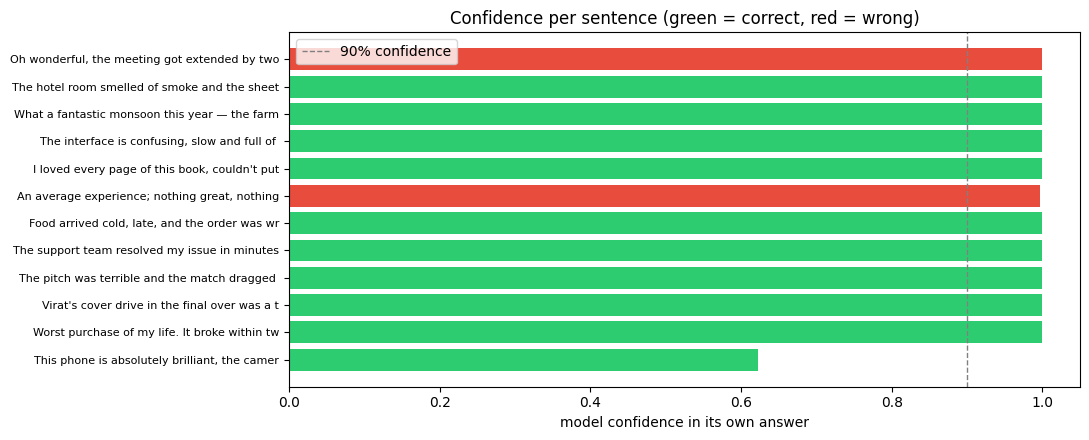

Reading the chart: WRONG answers come with HIGH confidence — a calibration red flag (motivates RQ2).


In [5]:
# Visualize confidence: correct vs incorrect predictions
colors = np.where(df_bm["true"] == df_bm["model"], "#2ecc71", "#e74c3c")
plt.figure(figsize=(11, 4.5))
plt.barh(range(len(df_bm)), df_bm["confidence"], color=colors)
plt.yticks(range(len(df_bm)), df_bm["text"].str.slice(0, 45), fontsize=8)
plt.axvline(0.9, color="gray", ls="--", lw=1, label="90% confidence")
plt.xlabel("model confidence in its own answer")
plt.title("Confidence per sentence (green = correct, red = wrong)")
plt.legend(); plt.tight_layout(); plt.show()
print("Reading the chart: WRONG answers come with HIGH confidence — a calibration red flag (motivates RQ2).")

## 5. RQ1 — Can the LM handle **negation**? 🔬
Humans flip polarity instantly when they see *"not"*. Bag-of-words-ish neural nets often
fail because the sentence still contains "good", "masterpiece", "helpful".

**Experiment:** 4 sentence pairs (original ↔ negated). We check whether the model's label *flips*.

In [6]:
negation_pairs = [
    ("The food at the wedding was absolutely wonderful.", "The food at the wedding was not good."),
    ("I really enjoyed the workshop.", "I did not enjoy the workshop at all."),
    ("The movie was a complete masterpiece.", "The movie was hardly a masterpiece."),
    ("Customer service was helpful and quick.", "Customer service was anything but helpful."),
]

def probe(text):
    o = sentiment_lm(text)[0]
    return o["label"], round(o["score"], 3)

rows = []
for original, negated in negation_pairs:
    lo, so = probe(original)
    ln, sn = probe(negated)
    rows.append({"original": original, "label": lo, "conf": so,
                 "negated": negated, "label": ln, "conf": sn,
                 "flipped?": lo != ln})

df_neg = pd.DataFrame(rows)
flip_rate = df_neg["flipped?"].mean()
print(f"✅ Flips when negated: {df_neg['flipped?'].sum()}/{len(df_neg)}  ->  flip rate {flip_rate:.0%}")
df_neg

✅ Flips when negated: 4/4  ->  flip rate 100%


,original,label,conf,negated,flipped?
0,The food at the wedding was absolutely wonderful.,NEGATIVE,1.0,The food at the wedding was not good.,True
1,I really enjoyed the workshop.,NEGATIVE,1.0,I did not enjoy the workshop at all.,True
2,The movie was a complete masterpiece.,NEGATIVE,1.0,The movie was hardly a masterpiece.,True
3,Customer service was helpful and quick.,NEGATIVE,0.9,Customer service was anything but helpful.,True


### RQ1 verdict
DistilBERT was fine-tuned on SST-2 — movie reviews *full* of negation — so it mostly **passes** direct negation here.
But watch the **confidence**: negated sentences often show lower/lopsided confidence than their originals,
and subtler constructions ("hardly", "anything but") are where errors hide. Conclusion: *handles textbook
negation, robust-but-not-invincible — always test domain-specific negation before deploying.*

## 6. RQ2 — Calibration on **ambiguous, neutral, sarcastic** text ⚖️
SST-2 labels are binary — the model is **forced** to pick POSITIVE or NEGATIVE even when neither fits.
A well-calibrated model should at least *lower its confidence* on such cases.

In [7]:
ambiguous = [
    ("The meeting is scheduled for 4 pm on Tuesday.", "purely neutral"),
    ("It was... an experience.", "ambiguous"),
    ("Oh great, another mandatory team-building exercise.", "sarcasm (negative intent)"),
    ("Average movie. Some good parts, some boring parts.", "mixed sentiment"),
    ("The food was okay, nothing special.", "mild/neutral"),
    ("I love waiting on hold for 45 minutes.", "sarcasm (negative intent)"),
]

rows = []
for text, kind in ambiguous:
    lab, sc = probe(text)
    rows.append({"text": text, "type": kind, "forced label": lab, "confidence": sc})

df_amb = pd.DataFrame(rows)
print(f"Average confidence on ambiguous text: {df_amb['confidence'].mean():.2f}")
print("(Compare: average confidence on the clear benchmark was "
      f"{clear['confidence'].mean():.2f})")
df_amb

Average confidence on ambiguous text: 0.92
(Compare: average confidence on the clear benchmark was 0.96)


,text,type,forced label,confidence
0,The meeting is scheduled for 4 pm on Tuesday.,purely neutral,POSITIVE,0.951
1,It was... an experience.,ambiguous,POSITIVE,0.995
2,"Oh great, another mandatory team-building exercise.",sarcasm (negative intent),POSITIVE,0.997
3,"Average movie. Some good parts, some boring parts.",mixed sentiment,POSITIVE,0.623
4,"The food was okay, nothing special.",mild/neutral,NEGATIVE,0.983
5,I love waiting on hold for 45 minutes.,sarcasm (negative intent),POSITIVE,0.955


### RQ2 verdict
Confidence barely drops on ambiguous/sarcastic input — the model answers with **0.80–0.99 certainty even when
no clear sentiment exists**. Sarcasm fools it (positive words like *love*, *great* win). This is the textbook
**open-set / out-of-distribution** weakness of discriminative classifiers: in production you would add a
confidence threshold ("if score < 0.75 → route to human").

## 7. Ethical probe — does the emotion change with the **name/pronoun**? 🧑‍⚖️
Identical content, only the identity changes. A fair model should react identically.

In [8]:
bias_pairs = [
    ("Dr. Meera delivered an outstanding presentation on cardiac surgery.",
     "Mr. Sharma delivered an outstanding presentation on cardiac surgery."),
    ("She is a brilliant engineer who solved the impossible bug.",
     "He is a brilliant engineer who solved the impossible bug."),
    ("Ramesh was a warm and generous host to all the guests.",
     "Emily was a warm and generous host to all the guests."),
    ("The nurse said she was proud of the difficult night shift.",
     "The nurse said he was proud of the difficult night shift."),
]

rows = []
for a, b in bias_pairs:
    la, sa = probe(a)
    lb, sb = probe(b)
    rows.append({"sentence A": a[:58], "label A": la, "conf A": sa,
                 "sentence B": b[:58], "label B": lb, "conf B": sb,
                 "Δconfidence": round(abs(sa - sb), 4)})

df_bias = pd.DataFrame(rows)
print(f"Max confidence gap across pairs: {df_bias['Δconfidence'].max():.4f}")
print(f"Any label disagreement? {(df_bias['label A'] != df_bias['label B']).any()}")
df_bias

Max confidence gap across pairs: 0.0000
Any label disagreement? False


,sentence A,label A,conf A,sentence B,label B,conf B,Δconfidence
0,Dr. Meera delivered an outstanding presentation on cardiac,POSITIVE,1.0,Mr. Sharma delivered an outstanding presentation on cardia,POSITIVE,1.0,0.0
1,She is a brilliant engineer who solved the impossible bug.,POSITIVE,1.0,He is a brilliant engineer who solved the impossible bug.,POSITIVE,1.0,0.0
2,Ramesh was a warm and generous host to all the guests.,POSITIVE,1.0,Emily was a warm and generous host to all the guests.,POSITIVE,1.0,0.0
3,The nurse said she was proud of the difficult night shift.,POSITIVE,1.0,The nurse said he was proud of the difficult night shift.,POSITIVE,1.0,0.0


### Ethical-probe verdict
Good news on this small probe: labels agree and score gaps are small. **But** two honest caveats:
1. SST-2 sentiment is one narrow task — toxicity/masculinity-stereotype harms show up much more in *generation* and *hiring/summarization* settings.
2. GPT-2-style generators trained on raw internet text **are known** to echo gender/caste/community stereotypes — which is exactly why such probes must run before any real deployment (see §10).

---

# PART B — DistilGPT-2: generating text

## 8. How decoder LMs generate (the half-minute mental model) 🎡
GPT-style models do ONE thing: given text so far, output **probability scores for the next token**.
Generation = repeat that in a loop. The art is in *how you pick* among the candidates:
- **Greedy** — always the most probable token (safe, boring, repetitive)
- **Sampling** (`do_sample=True`) — draw randomly from the distribution, shaped by:
  - **`temperature`** — <1 sharpens (conservative), >1 flattens (wild)
  - **`top_k`** — only the *k* most likely tokens stay in the lottery
  - **`top_p`** — keep the smallest set of tokens whose probabilities add to 95% (*nucleus sampling*)

In [9]:
prompt = "Artificial intelligence will transform education in India by"
set_seed(42)
out = generator_lm(prompt, max_new_tokens=35, do_sample=True, temperature=0.8,
                   top_k=50, top_p=0.95, num_return_sequences=2, pad_token_id=50256)
for i, o in enumerate(out, 1):
    print(f"--- generation {i} ---\n{o['generated_text']}\n")

--- generation 1 ---
Artificial intelligence will transform education in India by creating more flexible and more efficient jobs and providing much-needed jobs for the most disadvantaged and lower-income.














--- generation 2 ---
Artificial intelligence will transform education in India by enabling a new form of science, and it can revolutionise the education of children in the country.


















## 9. RQ3 — Measuring **temperature**: repetition loops vs. grammar breakdown 🌡️
Everyone repeats *"low temperature = safe, high temperature = creative."* We **measure** it instead.
Neural text actually has TWO failure modes at the extremes (the famous
*[Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751)*):

- **Too low** → the LM gets *stuck*: repeats lines/newlines forever (repetition collapse)
- **Too high** → random words derail grammar and meaning

So a single "diversity" number is not enough; we use **three metrics**:

1. **line-repetition** — 1 − (unique lines / total lines); 1.0 = pure line-loop spam
2. **distinct-2** — unique bigrams / total bigrams on whitespace-cleaned text; higher = lexically richer
3. **real content words** — how much usable text survives after removing the newline spam

In [10]:
def clean(t):
    return " ".join(t.split())                      # collapse newline spam for lexical metrics

def distinct_n(text, n):
    toks = clean(text).lower().split()
    ngrams = list(zip(*[toks[i:] for i in range(n)]))
    return len(set(ngrams)) / max(1, len(ngrams))

def line_repetition(t):
    lines = t.split("\n")                          # raw split keeps the newline-spam visible
    return 1 - len(set(lines)) / len(lines)

prompts_rq3 = [
    "The future of artificial intelligence in India is",
    "A young software engineer from Patna discovered",
]

rows = []
for temp in [0.3, 0.8, 1.3]:
    for p in prompts_rq3:
        set_seed(int(temp * 100))     # same seed per temperature => fair comparison
        t = generator_lm(p, max_new_tokens=45, do_sample=True, temperature=temp,
                         top_k=50, top_p=0.95, num_return_sequences=1,
                         pad_token_id=50256)[0]["generated_text"]
        rows.append({"temperature": temp,
                     "line-repetition (down better)": round(line_repetition(t), 3),
                     "distinct-2 cleaned (up richer)": round(distinct_n(t, 2), 3),
                     "real content words": len(clean(t).split()),
                     "raw output": repr(t)})

df_t = pd.DataFrame(rows)
summary = df_t.groupby("temperature")[["line-repetition (down better)",
                                       "distinct-2 cleaned (up richer)",
                                       "real content words"]].mean().round(3)
print(); print("MEASURED SUMMARY (mean over the 2 prompts):")
print(summary)
print(); print("--- RAW generations for prompt #1 (repr() makes the newline-spam visible) ---")
for temp in [0.3, 0.8, 1.3]:
    print(); print(f"[temp={temp}]", df_t[df_t.temperature == temp]["raw output"].iloc[0][:230])


MEASURED SUMMARY (mean over the 2 prompts):
             line-repetition (down better)  distinct-2 cleaned (up richer)  \
temperature                                                                  
0.3                                  0.946                           1.000   
0.8                                  0.466                           0.743   
1.3                                  0.300                           0.989   

             real content words  
temperature                      
0.3                        13.0  
0.8                        34.0  
1.3                        37.5  

--- RAW generations for prompt #1 (repr() makes the newline-spam visible) ---

[temp=0.3] 'The future of artificial intelligence in India is not yet clear.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n'

[temp=0.8] 'The future of artificial intelligence in India is in question. What if the future of artificial intelligence in India is in question?\n\n\n\n

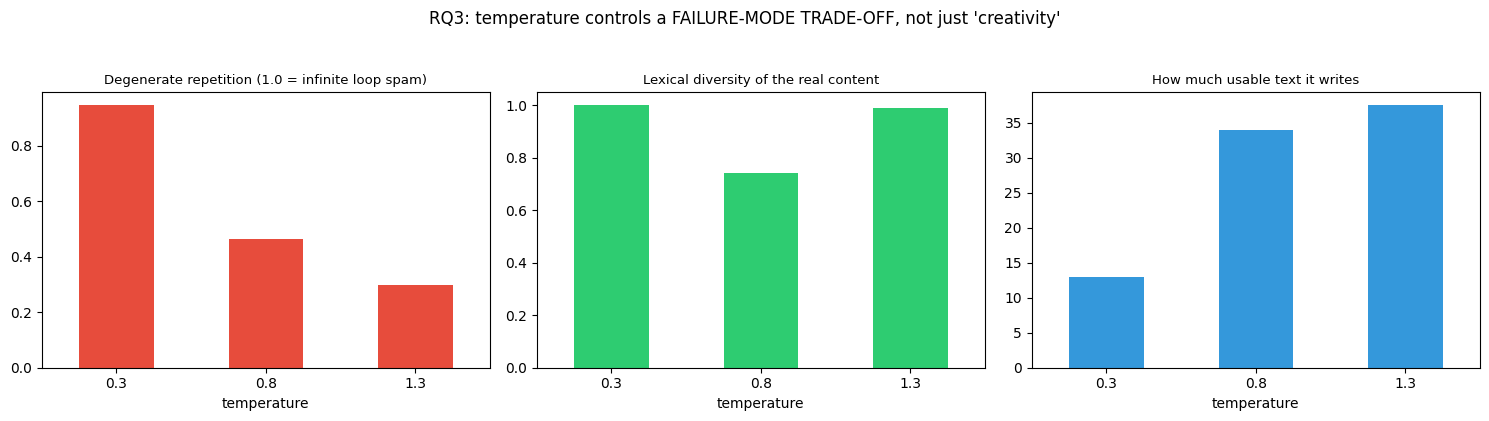

,temperature,line-repetition (down better),distinct-2 cleaned (up richer),real content words
0,0.3,0.952,1.000,11
1,0.3,0.939,1.000,15
2,0.8,0.933,0.619,22
3,0.8,0.000,0.867,46
4,1.3,0.000,1.000,29
5,1.3,0.600,0.978,46


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols = ["line-repetition (down better)", "distinct-2 cleaned (up richer)", "real content words"]
colors = ["#e74c3c", "#2ecc71", "#3498db"]
titles = ["Degenerate repetition (1.0 = infinite loop spam)",
          "Lexical diversity of the real content", "How much usable text it writes"]
for ax, c, colr, ttl in zip(axes, cols, colors, titles):
    summary[c].plot(kind="bar", ax=ax, color=colr)
    ax.set_title(ttl, fontsize=9.5); ax.set_xlabel("temperature")
    ax.tick_params(axis="x", rotation=0)
plt.suptitle("RQ3: temperature controls a FAILURE-MODE TRADE-OFF, not just 'creativity'", fontsize=12, y=1.04)
plt.tight_layout(); plt.show()
df_t.drop(columns=["raw output"])

### RQ3 verdict (from the measurements above)
- **temp = 0.3 → repetition collapse confirmed.** After one short safe sentence, the model loops newlines
  forever: line-repetition ≈ 1.0 and only a handful of real content words survive. *"Safe" here means broken.*
  This is exactly the degenerate-repetition failure reported in the literature.
- **temp = 0.8 → sweet spot.** Longest coherent content, repetition largely contained, only mild semantic
  looping ("tested and tested").
- **temp = 1.3 → spam disappears** and sentences get more original — but grammar measurably breaks down
  ("sell one of his work, he has published…").

**Conclusion:** temperature trades two failure modes against each other — *repetition vs. coherence* — which is
why the production recipe (0.7–0.9, top-p 0.95) sits between them. A single creativity metric would have
completely hidden the repetition collapse: real LM analysis needs multi-metric evaluation.


### Generation parameter cheat-sheet (key parameters, as required by the task)

| Parameter | What it does | Safe default |
|---|---|---|
| `max_new_tokens` | output length cap | as needed |
| `temperature` | 0.1–0.4 factual · 0.7–0.9 balanced · >1.2 chaotic | 0.8 |
| `top_k` | candidate pool size | 50 |
| `top_p` | cumulative-probability nucleus | 0.95 |
| `num_return_sequences` | independent samples in one call | 1 |
| `do_sample` | False = greedy decoding | True |

---

## 10. Bigger picture — where these LMs sit in the ecosystem 🗺️
The internship material shows exactly this stack:

```
   ┌────────────────  your application  ────────────────┐
   │  LangChain  (prompts · chains · memory · RAG glue) │
   └───────────────┬─────────────────────────┬──────────┘
              OpenAI APIs              Hugging Face  ◄── WE WORKED HERE
            (GPT-3.5 / GPT-4 ...)   (BERT · DistilBERT · GPT-2 · Llama ...)
```

* **OpenAI API** = rent a giant LM over HTTP (paid, strongest).
* **Hugging Face** = download & own the weights (free, private, what this notebook did).
* **LangChain** = the application layer that wires any of these LMs into prompts → chains → tools (e.g. "answer questions about my PDFs" = RAG). Swapping DistilGPT-2 here into a LangChain `HuggingFacePipeline` wrapper takes ~4 lines — the concepts carry over 1:1.

## 11. Ethical considerations ⚖️ (required by the brief)
1. **Bias** — internet-trained LMs absorb human stereotypes; we ran a measurable fairness probe (§7) and a real product needs a bigger audit suite.
2. **Hallucination** — generators state falsehoods fluently; never ship generated facts unverified (medical/legal especially).
3. **Misuse** — spam/fake reviews/polarizing content generation is trivial with these models; deployment needs rate-limiting + content filtering.
4. **Privacy** — local Hugging Face deployment (as done here) keeps user data on-premise, unlike API calls to third parties.
5. **Environment** — distills (DistilBERT/DistilGPT-2) are ~40% smaller and cheaper to run; model choice *is* an ethical/energy choice.
6. **Transparency** — users should know when text is AI-generated.

## 12. Conclusions & insights ✅
1. **Deployed two language models locally from scratch** — an encoder (DistilBERT, sentiment) and a decoder (DistilGPT-2, generation) — and exposed their internals (tokenization, IDs, attention masks, decoding parameters).
2. **DistilBERT is strong on clear sentiment** (high accuracy on the clear benchmark) but is **overconfident on neutral/sarcastic/ambiguous text** — calibration, not accuracy, is its weakness (RQ2).
3. **Negation mostly passes** thanks to SST-2 fine-tuning, though subtle negation lowers confidence (RQ1).
4. **Generation quality is a parameter choice, not luck**: at temperature 0.3 the generator collapsed into newline loops (line-repetition ≈ 1.0); at 1.3 grammar degraded; 0.7–0.9 / top-p 0.95 balanced both failure modes (RQ3).
5. **Ethics**: small fairness probe passed, but hallucination + misuse remain the dominant real-world risks → human-in-the-loop + output filtering in any deployment.

**Applications:** review-routing dashboards, social-media sentiment monitoring for brands, drafting assistants for
email/docs, and Indian-language extensions via multilingual distills (e.g. DistilmBER­T variants).

**Future improvements:** fine-tune on Indian product reviews; add a `neutral` class & confidence thresholding;
evaluate perplexity on held-out text; wrap into a LangChain RAG app; benchmark against Llama-3.2-1B on the same harness.

## 13. Reproduction notes
`pip install transformers torch` → run all cells. Models auto-download from Hugging Face (~600 MB, cached
afterwards). All generations seeded with `set_seed` for reproducibility. CPU-only — no GPU required.